## Projeto de Regressão Múltipla: Comparação e Validação de Modelos

Este notebook é dedicado à construção e comparação de modelos de regressão linear para predizer a progressão da doença diabética, utilizando o famoso dataset de diabetes do `sklearn`. Nosso objetivo principal é ir além da simples construção de modelos, focando na **avaliação comparativa** de diferentes configurações de modelos e, crucialmente, na **validação das suposições do Modelo de Mínimos Quadrados Ordinários (MQO)** para cada um deles.

Uma comparação de modelos eficaz não se baseia apenas em métricas de desempenho como R-quadrado, MAE ou MSE. É fundamental assegurar que os modelos satisfazem os pressupostos subjacentes à regressão linear. A violação desses pressupostos pode levar a conclusões errôneas sobre a significância dos preditores, a intervalos de confiança imprecisos e a predições enviesadas.

### Estrutura da Análise:

1.  **Preparação do Ambiente e Carregamento dos Dados**
2.  **Análise Exploratória dos Dados (Dataset de Diabetes)**
3.  **Modelagem e Comparação de Modelos (Dataset de Diabetes)**
    * Construção de múltiplos modelos de regressão linear.
    * Cálculo e comparação de métricas de desempenho (MAE, MSE, AIC, BIC, R²).
    * Análise detalhada dos testes de suposição para cada modelo.

## Comparando modelos utilizando as métricas de avaliação de modelos

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd # Para manipulação e análise de dados em DataFrame
import numpy as np # Para operações numéricas e arrays
import matplotlib.pyplot as plt # Para criação de gráficos estáticos
import seaborn as sns # Para visualização de dados estatísticos (baseado no matplotlib)
import statsmodels.api as sm # Para modelos estatísticos, incluindo regressão linear (OLS)
from sklearn.model_selection import train_test_split # Para dividir dados em treino/teste (útil para modelos mais complexos, mas não usado diretamente aqui)
from sklearn import datasets # Para carregar datasets de exemplo, como o de diabetes

# Bibliotecas adicionais para testes de suposição
from statsmodels.graphics.gofplots import qqplot # Para Q-Q plots (teste de normalidade)
from statsmodels.graphics.tsaplots import plot_acf # Para plotar a função de autocorrelação (ACF)
from statsmodels.stats.diagnostic import het_breuschpagan, het_white # Testes de homocedasticidade (Breusch-Pagan, White)
from statsmodels.stats.stattools import durbin_watson # Teste de Durbin-Watson (autocorrelação)
from statsmodels.stats.outliers_influence import variance_inflation_factor # Para VIF (multicolinearidade)
from scipy import stats # Para funções estatísticas, incluindo testes de normalidade (Shapiro-Wilk)

import warnings
warnings.filterwarnings("ignore") # Ignora avisos para uma saída mais limpa

### 1. Preparação do Ambiente e Carregamento dos Dados (Dataset de Diabetes)

Nesta seção, carregaremos o dataset de diabetes do `sklearn`, que é um conjunto de dados amplamente utilizado para exemplos de regressão.

#### Contextualização do Dataset de Diabetes:

O conjunto de dados de diabetes contém 10 variáveis preditoras fisiológicas (idade, sexo, índice de massa corporal, pressão arterial média, seis medidas de soro sanguíneo) e uma variável alvo que representa uma medida quantitativa da progressão da doença de diabetes após um ano. As variáveis numéricas já foram normalizadas para ter média 0 e variância 1 para facilitar a modelagem.

As variáveis presentes no conjunto de dados são:

* `age`: Idade do paciente.
* `sex`: Gênero do paciente (valores binários que podem representar 0: feminino, 1: masculino, ou valores padronizados).
* `bmi`: Índice de massa corporal (IMC).
* `bp`: Pressão arterial média.
* `s1`: Total de soro de lipoproteína de alta densidade (HDL).
* `s2`: Total de soro de lipoproteína de baixa densidade (LDL).
* `s3`: Total de soro de triglicerídeos.
* `s4`: Total de soro de total de lipoproteína.
* `s5`: Total de soro de ácido sérico.
* `s6`: Total de soro de lamotrigina.

O objetivo é prever a medida quantitativa da progressão da doença diabética após um ano (`target` ou `progressao`) com base nessas características.

In [2]:
# Carregando o dataset de diabetes do sklearn
data = datasets.load_diabetes()

# Separando as variáveis preditoras (X) e a variável alvo (y)
X = data.data
y = data.target

# Obtendo os nomes das features
feature_names = data.feature_names

### 2. Análise Exploratória dos Dados (Dataset de Diabetes)

Vamos realizar uma análise exploratória para entender a estrutura, as dimensões e as características básicas do dataset.

#### Verificando os nomes das variáveis e dimensões

In [3]:
print("Nomes das variáveis preditoras:")
print(feature_names) # nome das variaveis

print(f"\nTamanho da base de dados (variáveis preditoras): {data.data.shape}") # tamanho da base de dados
print(f"Tamanho da variável alvo: {data.target.shape}")

Nomes das variáveis preditoras:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Tamanho da base de dados (variáveis preditoras): (442, 10)
Tamanho da variável alvo: (442,)


#### Criando um DataFrame para facilitar as análises

Transformaremos os dados em um DataFrame pandas para uma manipulação mais fácil e para adicionar a variável alvo.

In [4]:
db_df = pd.DataFrame(data.data, columns=data.feature_names)
db_df['progressao'] = data.target

print("Primeiras 5 linhas do DataFrame de Diabetes:")
db_df.head()

Primeiras 5 linhas do DataFrame de Diabetes:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progressao
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


#### Verificando valores ausentes e tipos de dados

É crucial garantir que não há valores ausentes e que os tipos de dados estão corretos antes de prosseguir com a modelagem.

In [5]:
print("Verificando valores ausentes por coluna:")
print(db_df.isna().sum()) # verificando valores ausentes

Verificando valores ausentes por coluna:
age           0
sex           0
bmi           0
bp            0
s1            0
s2            0
s3            0
s4            0
s5            0
s6            0
progressao    0
dtype: int64


In [6]:
print("\nTipos de dados das variáveis:")
print(db_df.info())


Tipos de dados das variáveis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         442 non-null    float64
 1   sex         442 non-null    float64
 2   bmi         442 non-null    float64
 3   bp          442 non-null    float64
 4   s1          442 non-null    float64
 5   s2          442 non-null    float64
 6   s3          442 non-null    float64
 7   s4          442 non-null    float64
 8   s5          442 non-null    float64
 9   s6          442 non-null    float64
 10  progressao  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None


#### Análise Descritiva das Medidas de Tendência Central e Dispersão

Um sumário estatístico fornece insights rápidos sobre a distribuição das variáveis numéricas.

In [7]:
pd.options.display.float_format = '{:.2f}'.format # Formata a exibição de floats para 2 casas decimais
print("Sumário estatístico das variáveis numéricas:")
db_df.describe()

Sumário estatístico das variáveis numéricas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progressao
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


Observações sobre o sumário descritivo:
- As variáveis preditoras (age a s6) já estão padronizadas com média próxima de 0 e desvio padrão próximo de 0.05, o que é ideal para alguns algoritmos, mas para OLS do `statsmodels`, a padronização não é estritamente necessária.
- A variável 'progressao' (alvo) tem uma média de 152.13 e desvio padrão de 77.09, com valores que variam de 25 a 346.

#### Análise gráfica

A análise gráfica é uma maneira eficaz de entender as relações entre variáveis e identificar padrões ou problemas nos dados, como a presença de outliers ou distribuições não normais.

O `pairplot` cria um conjunto de gráficos de dispersão entre todas as variáveis, além de exibir histogramas na diagonal. Isso permite visualizar rapidamente as relações bivariadas e as distribuições de cada variável. O `heatmap` da matriz de correlação visualiza a força e direção das relações lineares entre as variáveis.
Python

--- Matriz de Correlação entre as variáveis --- 


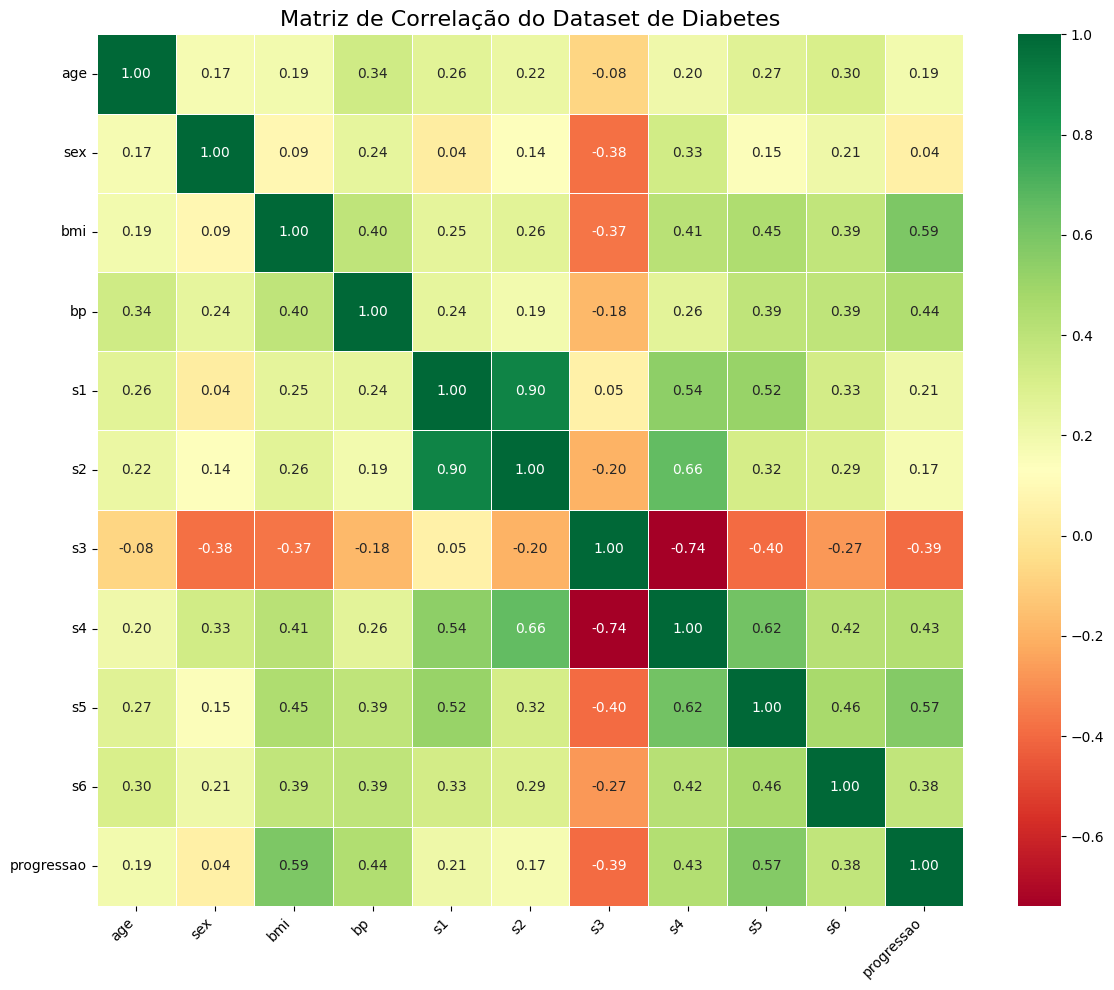

In [8]:
# Análise gráfica - Pairplot (pode ser lento para muitos dados/variáveis)
# Para este dataset, que tem 11 variáveis, o pairplot pode ser muito denso.
# Vamos optar por plotar as correlações e, se necessário, distribuições individuais.

# Plotando a matriz de correlação
print("--- Matriz de Correlação entre as variáveis --- ")
correlation_matrix = db_df.corr()
plt.figure(figsize=(12, 10)) # Aumentar o tamanho para melhor visualização
sns.heatmap(correlation_matrix, annot=True, cmap="RdYlGn", fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlação do Dataset de Diabetes", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Observações sobre a Matriz de Correlação:
A matriz de correlação nos ajuda a identificar as variáveis que possuem maior relação linear com a variável alvo 'progressao', bem como entre as próprias variáveis preditoras (potencial multicolinearidade).

Maiores correlações com a 'progressao':
  - `bmi` (Índice de Massa Corporal): 0.59 (Correlação positiva forte)
  - `s5` (Total de Soro de Ácido Sérico): 0.57 (Correlação positiva forte)
  - `bp` (Pressão Arterial Média): 0.44 (Correlação positiva moderada)
  - `s4` (Total de Soro de Total de Lipoproteína): 0.43 (Correlação positiva moderada)
  - `s3` (Total de Soro de Triglicerídeos): -0.39 (Correlação negativa moderada)

Potencial Multicolinearidade entre Preditoras:
- Observamos altas correlações entre algumas variáveis preditoras, como `s1`, `s2`, `s3`, `s4`, `s5`. Por exemplo, `s1` e `s2` têm uma correlação de 0.89, e `s4` e `s3` têm -0.74. Isso indica a presença de multicolinearidade, que deve ser diagnosticada e gerenciada para garantir a estabilidade e interpretabilidade dos coeficientes do modelo. O VIF (Variance Inflation Factor) será crucial para isso.

### 3. Modelagem e Comparação de Modelos (Dataset de Diabetes)

Vamos construir uma série de modelos de regressão linear, começando com as variáveis mais correlacionadas e adicionando-as sequencialmente. Para cada modelo, avaliaremos suas métricas de desempenho e, crucialmente, realizaremos os **testes de suposição** para verificar sua validade.

#### Teoria sobre Métricas de Comparação:

* **R-quadrado (R²):** Proporção da variância na variável dependente que é previsível a partir das variáveis independentes. Quanto mais próximo de 1, melhor o ajuste.
* **MAE (Mean Absolute Error):** Média dos valores absolutos dos erros. Mede a magnitude média dos erros sem considerar sua direção. Uma MAE menor indica um modelo mais preciso.
* **MSE (Mean Squared Error):** Média dos quadrados dos erros. Penaliza erros maiores mais severamente. Uma MSE menor indica um modelo mais preciso.
* **AIC (Akaike Information Criterion) e BIC (Bayesian Information Criterion):** São critérios de informação que avaliam a qualidade de um modelo estatístico em relação a outros modelos. Eles penalizam a complexidade do modelo (número de variáveis) para evitar overfitting. Modelos com **menores valores de AIC e BIC** são geralmente preferidos. O BIC penaliza mais fortemente modelos com mais parâmetros do que o AIC, tendendo a selecionar modelos mais parcimoniosos.

#### Inicializando lista para armazenar resultados

In [9]:
results = []

#### Modelo 1: Regressão Linear Simples com `bmi`

Construiremos o primeiro modelo utilizando apenas a variável `bmi`, que apresentou a maior correlação com a `progressao`.
Python



In [10]:
print("--- Análise do Modelo 1: progressao ~ bmi ---")
lm1 = sm.OLS.from_formula("progressao ~ bmi", data=db_df)
model_1 = lm1.fit()
print(model_1.summary(title='Sumário do Modelo 1: progressao ~ bmi'))

# Armazenando métricas
results.append({
    'Modelo': 'Modelo 1 (bmi)',
    'MAE': np.mean(np.abs(y - model_1.predict())),
    'MSE': np.mean((y - model_1.predict())**2),
    'AIC': model_1.aic,
    'BIC': model_1.bic,
    'R²': model_1.rsquared
})

--- Análise do Modelo 1: progressao ~ bmi ---
                    Sumário do Modelo 1: progressao ~ bmi                     
Dep. Variable:             progressao   R-squared:                       0.344
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     230.7
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.47e-42
Time:                        21:06:36   Log-Likelihood:                -2454.0
No. Observations:                 442   AIC:                             4912.
Df Residuals:                     440   BIC:                             4920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interc


**1. Normalidade dos Resíduos (Modelo 1):**


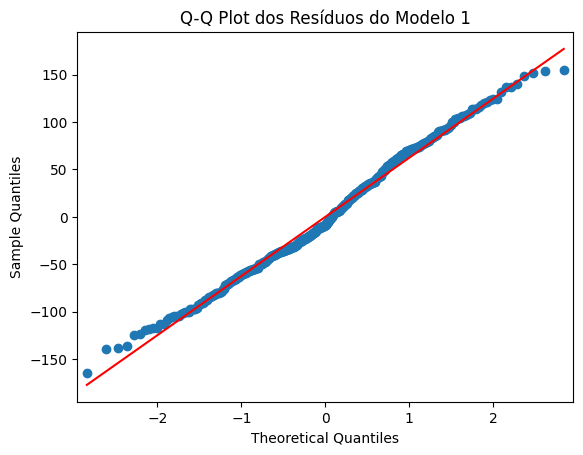

Interpretação do Q-Q Plot: Os pontos se desviam das caudas da linha diagonal, sugerindo uma leve não-normalidade.


In [11]:
# Resíduos do modelo 1
residuos1 = model_1.resid
fitted_values1 = model_1.fittedvalues

# 1. Normalidade dos Resíduos
print("\n**1. Normalidade dos Resíduos (Modelo 1):**")
# Teste Gráfico: Q-Q Plot
qqplot(residuos1, line='s')
plt.title("Q-Q Plot dos Resíduos do Modelo 1")
plt.show()
print("Interpretação do Q-Q Plot: Os pontos se desviam das caudas da linha diagonal, sugerindo uma leve não-normalidade.")


In [12]:
# Teste Estatístico: Shapiro-Wilk (ou Jarque-Bera do summary)
shapiro_test1 = stats.shapiro(residuos1)
print(f"Shapiro-Wilk: Estatística={shapiro_test1.statistic:.4f}, P-valor={shapiro_test1.pvalue:.4f}")
if shapiro_test1.pvalue < 0.05:
    print("Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal. Isso afeta a validade dos intervalos de confiança e testes de hipóteses.")
else:
    print("Conclusão: Não rejeitamos H0. Resíduos seguem uma distribuição normal.")


Shapiro-Wilk: Estatística=0.9904, P-valor=0.0054
Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal. Isso afeta a validade dos intervalos de confiança e testes de hipóteses.



**2. Homocedasticidade (Modelo 1):**


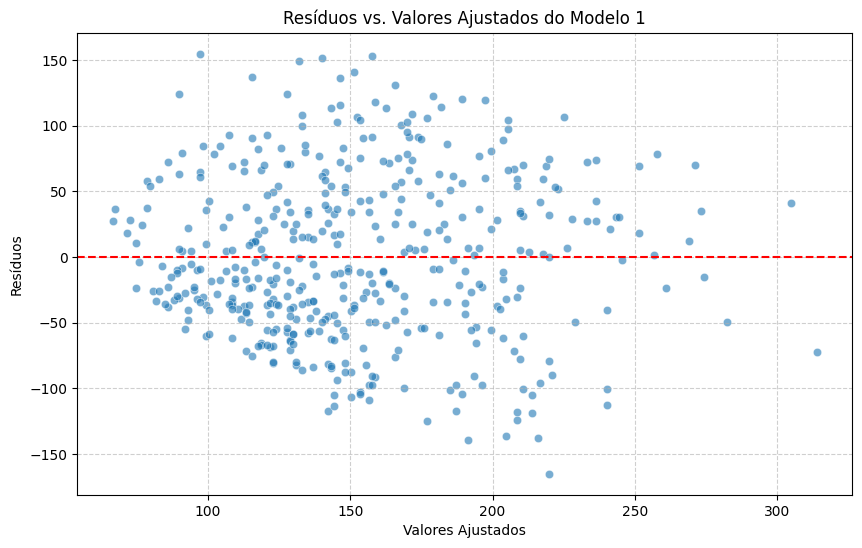

In [13]:
# 2. Homocedasticidade
print("\n**2. Homocedasticidade (Modelo 1):**")
# Teste Gráfico: Resíduos vs. Valores Ajustados
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values1, y=residuos1, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs. Valores Ajustados do Modelo 1')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [14]:
# Teste Estatístico: Breusch-Pagan
bp_test1 = het_breuschpagan(residuos1, model_1.model.exog)
print(f"Breusch-Pagan: Estatística LM={bp_test1[0]:.4f}, P-valor LM={bp_test1[1]:.4f}")
if bp_test1[1] < 0.05:
    print("Conclusão: Rejeitamos H0 (homocedasticidade). Há evidências de heterocedasticidade.")
else:
    print("Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.")
  

Breusch-Pagan: Estatística LM=11.1213, P-valor LM=0.0009
Conclusão: Rejeitamos H0 (homocedasticidade). Há evidências de heterocedasticidade.



**3. Ausência de Autocorrelação (Modelo 1):**


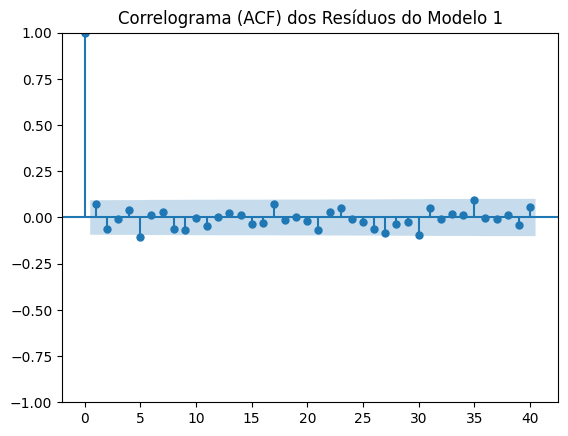

In [15]:
# 3. Ausência de Autocorrelação
print("\n**3. Ausência de Autocorrelação (Modelo 1):**")
# Teste Gráfico: ACF Plot
plot_acf(residuos1, lags=40)
plt.title('Correlograma (ACF) dos Resíduos do Modelo 1')
plt.show()

In [16]:
# Teste Estatístico: Durbin-Watson
dw_stat1 = durbin_watson(residuos1)
print(f"Durbin-Watson: {dw_stat1:.4f}")
if 1.5 < dw_stat1 < 2.5:
    print("Conclusão: Ausência de autocorrelação de primeira ordem.")
else:
    print("Conclusão: Autocorrelação de primeira ordem presente.")

Durbin-Watson: 1.8482
Conclusão: Ausência de autocorrelação de primeira ordem.


#### Modelo 2: Adicionando `s5`

Adicionamos a segunda variável mais correlacionada, `s5`, ao modelo.

--- Análise do Modelo 2: progressao ~ bmi + s5 ---
                  Sumário do Modelo 2: progressao ~ bmi + s5                  
Dep. Variable:             progressao   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     186.6
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.25e-59
Time:                        21:12:37   Log-Likelihood:                -2411.2
No. Observations:                 442   AIC:                             4828.
Df Residuals:                     439   BIC:                             4841.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
I

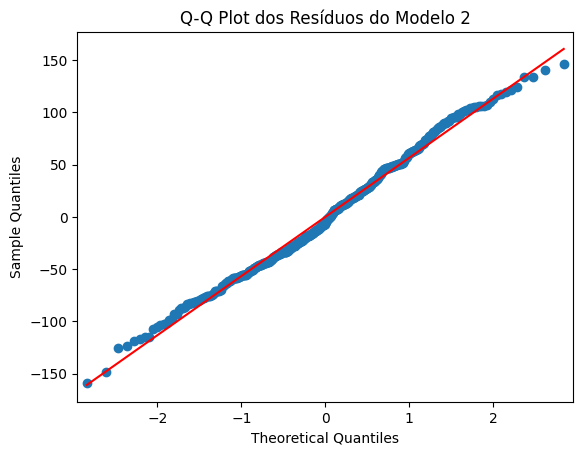

Shapiro-Wilk: Estatística=0.9914, P-valor=0.0119
Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.

**2. Homocedasticidade (Modelo 2):**


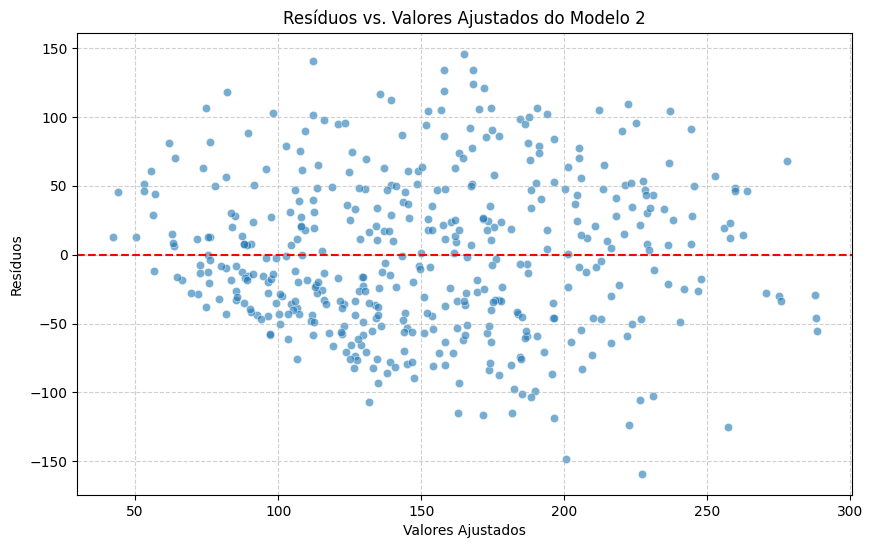

Breusch-Pagan: Estatística LM=11.6164, P-valor LM=0.0030
Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.

**3. Ausência de Autocorrelação (Modelo 2):**


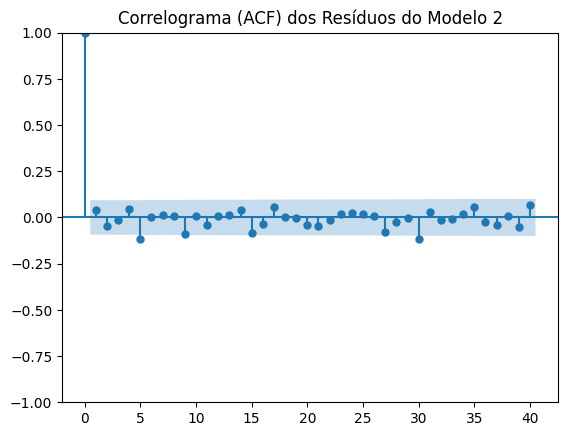

Durbin-Watson: 1.9186
Conclusão: Ausência de autocorrelação de primeira ordem.


In [17]:
print("--- Análise do Modelo 2: progressao ~ bmi + s5 ---")
lm2 = sm.OLS.from_formula("progressao ~ bmi+s5", data=db_df)
model_2 = lm2.fit()
print(model_2.summary(title='Sumário do Modelo 2: progressao ~ bmi + s5'))

# Armazenando métricas
results.append({
    'Modelo': 'Modelo 2 (bmi+s5)',
    'MAE': np.mean(np.abs(y - model_2.predict())),
    'MSE': np.mean((y - model_2.predict())**2),
    'AIC': model_2.aic,
    'BIC': model_2.bic,
    'R²': model_2.rsquared
})

print("\n--- Testes de Suposição para o Modelo 2 ---")
# Resíduos do modelo 2
residuos2 = model_2.resid
fitted_values2 = model_2.fittedvalues

# 1. Normalidade dos Resíduos
print("\n**1. Normalidade dos Resíduos (Modelo 2):**")
qqplot(residuos2, line='s')
plt.title("Q-Q Plot dos Resíduos do Modelo 2")
plt.show()
shapiro_test2 = stats.shapiro(residuos2)
print(f"Shapiro-Wilk: Estatística={shapiro_test2.statistic:.4f}, P-valor={shapiro_test2.pvalue:.4f}")
if shapiro_test2.pvalue < 0.05:
    print("Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.")
else:
    print("Conclusão: Não rejeitamos H0. Resíduos seguem uma distribuição normal.")

# 2. Homocedasticidade
print("\n**2. Homocedasticidade (Modelo 2):**")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values2, y=residuos2, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs. Valores Ajustados do Modelo 2')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
bp_test2 = het_breuschpagan(residuos2, model_2.model.exog)
print(f"Breusch-Pagan: Estatística LM={bp_test2[0]:.4f}, P-valor LM={bp_test2[1]:.4f}")
if bp_test2[1] < 0.05:
    print("Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.")
else:
    print("Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.")

# 3. Ausência de Autocorrelação
print("\n**3. Ausência de Autocorrelação (Modelo 2):**")
plot_acf(residuos2, lags=40)
plt.title('Correlograma (ACF) dos Resíduos do Modelo 2')
plt.show()
dw_stat2 = durbin_watson(residuos2)
print(f"Durbin-Watson: {dw_stat2:.4f}")
if 1.5 < dw_stat2 < 2.5:
    print("Conclusão: Ausência de autocorrelação de primeira ordem.")
else:
    print("Conclusão: Autocorrelação de primeira ordem presente.")


#### Modelo 3: Adicionando `bp`

Adicionamos a variável `bp` (pressão arterial média) ao modelo.

--- Análise do Modelo 3: progressao ~ bmi + s5 + bp ---
               Sumário do Modelo 3: progressao ~ bmi + s5 + bp                
Dep. Variable:             progressao   R-squared:                       0.480
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     134.8
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           7.16e-62
Time:                        21:14:18   Log-Likelihood:                -2402.6
No. Observations:                 442   AIC:                             4813.
Df Residuals:                     438   BIC:                             4830.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

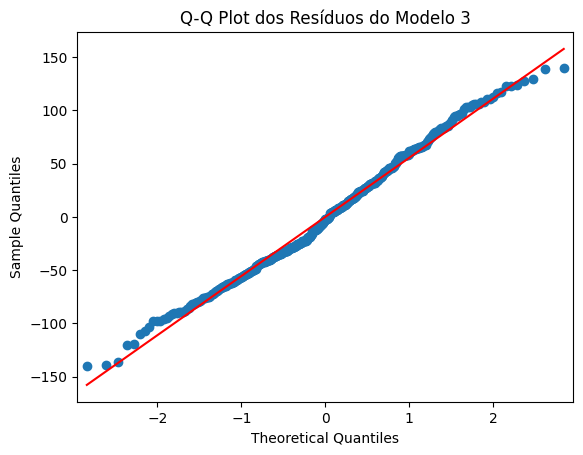

Shapiro-Wilk: Estatística=0.9905, P-valor=0.0060
Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.

**2. Homocedasticidade (Modelo 3):**


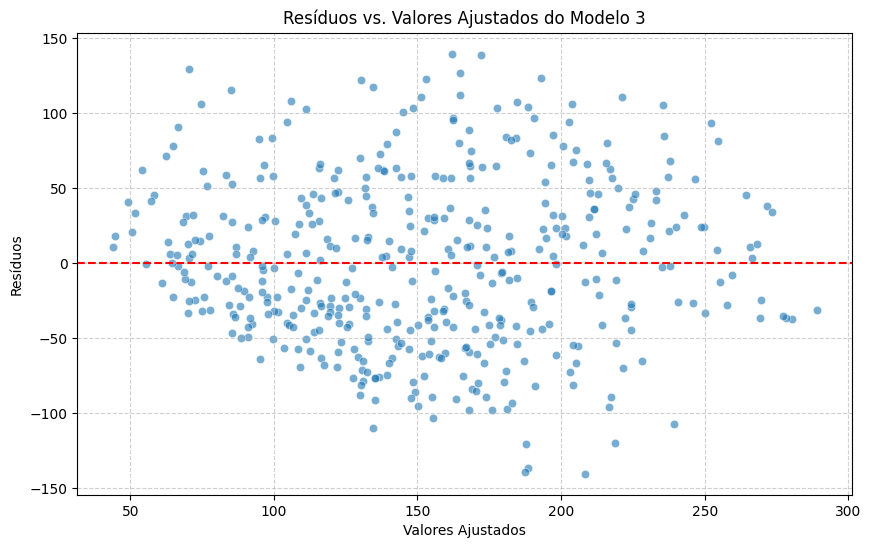

Breusch-Pagan: Estatística LM=7.4402, P-valor LM=0.0591
Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.

**3. Ausência de Autocorrelação (Modelo 3):**


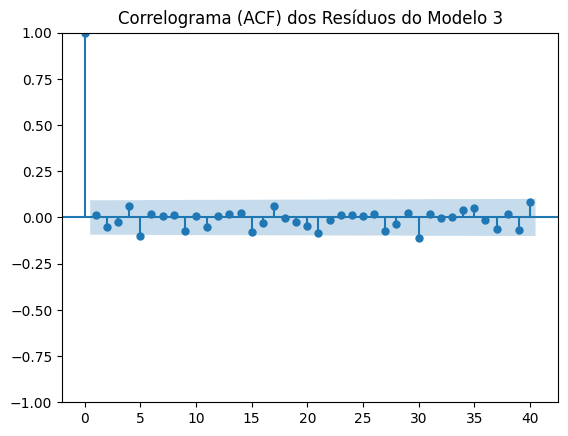

Durbin-Watson: 1.9706
Conclusão: Ausência de autocorrelação de primeira ordem.


In [18]:
print("--- Análise do Modelo 3: progressao ~ bmi + s5 + bp ---")
lm3 = sm.OLS.from_formula("progressao ~ bmi+s5+bp", data=db_df)
model_3 = lm3.fit()
print(model_3.summary(title='Sumário do Modelo 3: progressao ~ bmi + s5 + bp'))

# Armazenando métricas
results.append({
    'Modelo': 'Modelo 3 (bmi+s5+bp)',
    'MAE': np.mean(np.abs(y - model_3.predict())),
    'MSE': np.mean((y - model_3.predict())**2),
    'AIC': model_3.aic,
    'BIC': model_3.bic,
    'R²': model_3.rsquared
})

print("\n--- Testes de Suposição para o Modelo 3 ---")
# Resíduos do modelo 3
residuos3 = model_3.resid
fitted_values3 = model_3.fittedvalues

# 1. Normalidade dos Resíduos
print("\n**1. Normalidade dos Resíduos (Modelo 3):**")
qqplot(residuos3, line='s')
plt.title("Q-Q Plot dos Resíduos do Modelo 3")
plt.show()
shapiro_test3 = stats.shapiro(residuos3)
print(f"Shapiro-Wilk: Estatística={shapiro_test3.statistic:.4f}, P-valor={shapiro_test3.pvalue:.4f}")
if shapiro_test3.pvalue < 0.05:
    print("Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.")
else:
    print("Conclusão: Não rejeitamos H0. Resíduos seguem uma distribuição normal.")

# 2. Homocedasticidade
print("\n**2. Homocedasticidade (Modelo 3):**")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values3, y=residuos3, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs. Valores Ajustados do Modelo 3')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
bp_test3 = het_breuschpagan(residuos3, model_3.model.exog)
print(f"Breusch-Pagan: Estatística LM={bp_test3[0]:.4f}, P-valor LM={bp_test3[1]:.4f}")
if bp_test3[1] < 0.05:
    print("Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.")
else:
    print("Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.")

# 3. Ausência de Autocorrelação
print("\n**3. Ausência de Autocorrelação (Modelo 3):**")
plot_acf(residuos3, lags=40)
plt.title('Correlograma (ACF) dos Resíduos do Modelo 3')
plt.show()
dw_stat3 = durbin_watson(residuos3)
print(f"Durbin-Watson: {dw_stat3:.4f}")
if 1.5 < dw_stat3 < 2.5:
    print("Conclusão: Ausência de autocorrelação de primeira ordem.")
else:
    print("Conclusão: Autocorrelação de primeira ordem presente.")

#### Modelo 4: Adicionando `s4`

Adicionamos a variável `s4` ao modelo.

--- Análise do Modelo 4: progressao ~ bmi + s5 + bp + s4 ---
             Sumário do Modelo 4: progressao ~ bmi + s5 + bp + s4             
Dep. Variable:             progressao   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     101.4
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           5.41e-61
Time:                        21:16:00   Log-Likelihood:                -2402.1
No. Observations:                 442   AIC:                             4814.
Df Residuals:                     437   BIC:                             4835.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

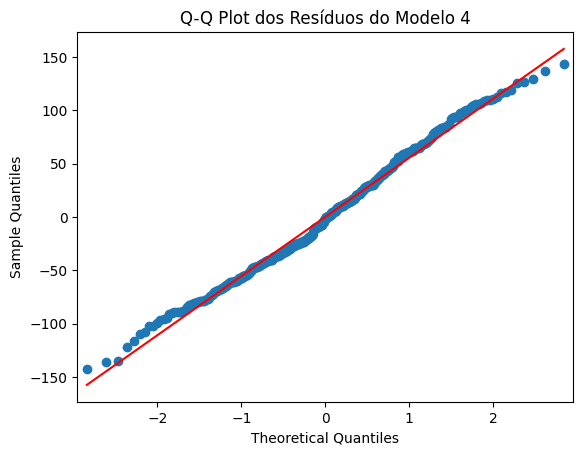

Shapiro-Wilk: Estatística=0.9905, P-valor=0.0062
Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.

**2. Homocedasticidade (Modelo 4):**


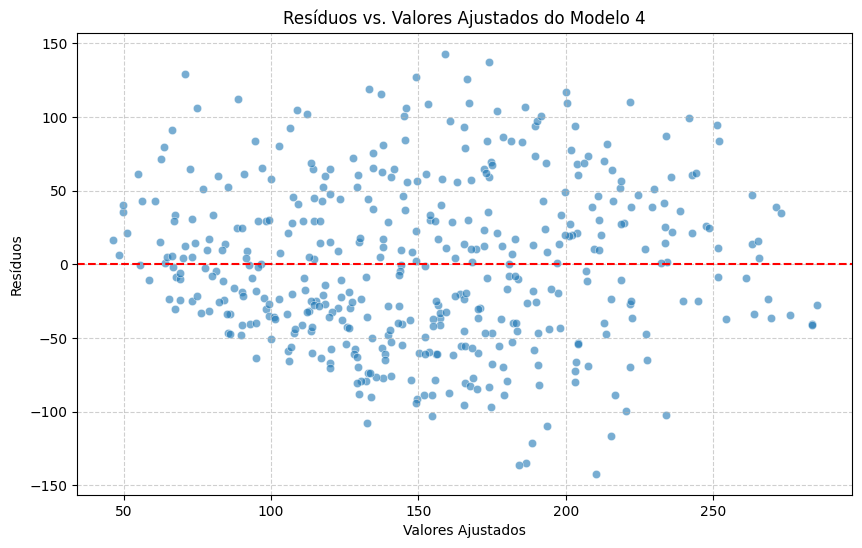

Breusch-Pagan: Estatística LM=8.2918, P-valor LM=0.0815
Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.

**3. Ausência de Autocorrelação (Modelo 4):**


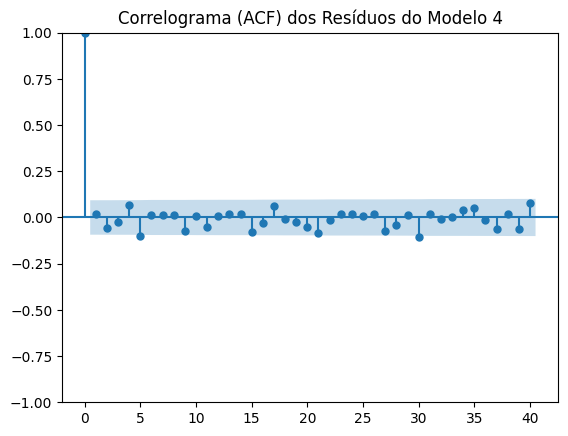

Durbin-Watson: 1.9561
Conclusão: Ausência de autocorrelação de primeira ordem.


In [19]:
print("--- Análise do Modelo 4: progressao ~ bmi + s5 + bp + s4 ---")
lm4 = sm.OLS.from_formula("progressao ~ bmi+s5+bp+s4", data=db_df)
model_4 = lm4.fit()
print(model_4.summary(title='Sumário do Modelo 4: progressao ~ bmi + s5 + bp + s4'))

# Armazenando métricas
results.append({
    'Modelo': 'Modelo 4 (bmi+s5+bp+s4)',
    'MAE': np.mean(np.abs(y - model_4.predict())),
    'MSE': np.mean((y - model_4.predict())**2),
    'AIC': model_4.aic,
    'BIC': model_4.bic,
    'R²': model_4.rsquared
})

print("\n--- Testes de Suposição para o Modelo 4 ---")
# Resíduos do modelo 4
residuos4 = model_4.resid
fitted_values4 = model_4.fittedvalues

# 1. Normalidade dos Resíduos
print("\n**1. Normalidade dos Resíduos (Modelo 4):**")
qqplot(residuos4, line='s')
plt.title("Q-Q Plot dos Resíduos do Modelo 4")
plt.show()
shapiro_test4 = stats.shapiro(residuos4)
print(f"Shapiro-Wilk: Estatística={shapiro_test4.statistic:.4f}, P-valor={shapiro_test4.pvalue:.4f}")
if shapiro_test4.pvalue < 0.05:
    print("Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.")
else:
    print("Conclusão: Não rejeitamos H0. Resíduos seguem uma distribuição normal.")

# 2. Homocedasticidade
print("\n**2. Homocedasticidade (Modelo 4):**")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values4, y=residuos4, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs. Valores Ajustados do Modelo 4')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
bp_test4 = het_breuschpagan(residuos4, model_4.model.exog)
print(f"Breusch-Pagan: Estatística LM={bp_test4[0]:.4f}, P-valor LM={bp_test4[1]:.4f}")
if bp_test4[1] < 0.05:
    print("Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.")
else:
    print("Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.")

# 3. Ausência de Autocorrelação
print("\n**3. Ausência de Autocorrelação (Modelo 4):**")
plot_acf(residuos4, lags=40)
plt.title('Correlograma (ACF) dos Resíduos do Modelo 4')
plt.show()
dw_stat4 = durbin_watson(residuos4)
print(f"Durbin-Watson: {dw_stat4:.4f}")
if 1.5 < dw_stat4 < 2.5:
    print("Conclusão: Ausência de autocorrelação de primeira ordem.")
else:
    print("Conclusão: Autocorrelação de primeira ordem presente.")


#### Modelo 5: Adicionando `s3`

Adicionamos a variável `s3` ao modelo.

--- Análise do Modelo 5: progressao ~ bmi + s5 + bp + s4 + s3 ---
          Sumário do Modelo 5: progressao ~ bmi + s5 + bp + s4 + s3           
Dep. Variable:             progressao   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     105.6
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           7.24e-63
Time:                        21:16:46   Log-Likelihood:                -2397.7
No. Observations:                 442   AIC:                             4805.
Df Residuals:                     437   BIC:                             4826.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

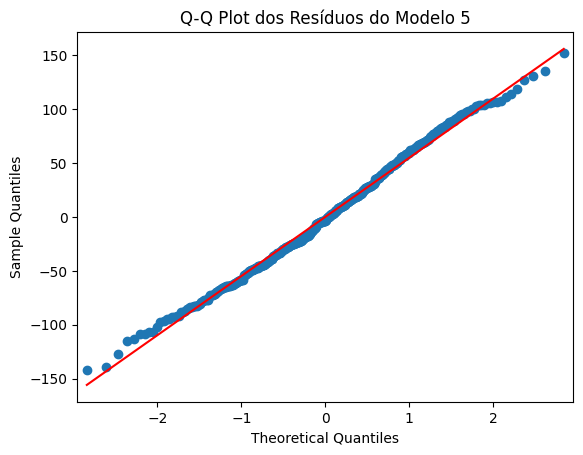

Shapiro-Wilk: Estatística=0.9933, P-valor=0.0471
Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.

**2. Homocedasticidade (Modelo 5):**


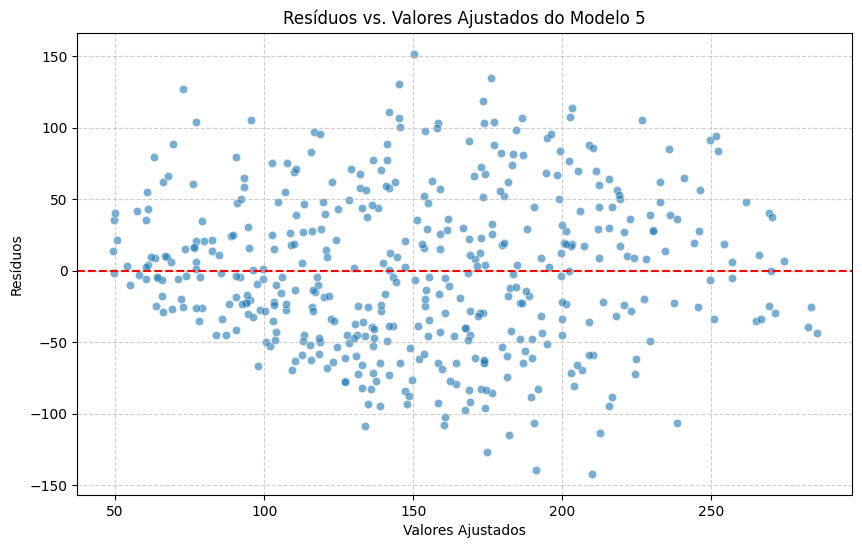

Breusch-Pagan: Estatística LM=13.1779, P-valor LM=0.0104
Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.

**3. Ausência de Autocorrelação (Modelo 5):**


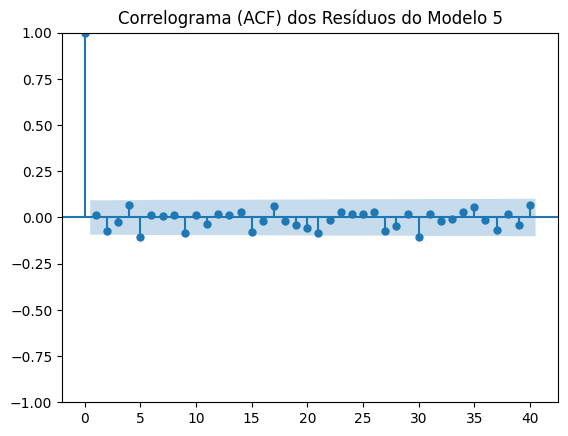

Durbin-Watson: 1.9703
Conclusão: Ausência de autocorrelação de primeira ordem.


In [20]:
print("--- Análise do Modelo 5: progressao ~ bmi + s5 + bp + s4 + s3 ---")
lm5 = sm.OLS.from_formula("progressao ~ bmi+s5+bp+s3", data=db_df)
model_5 = lm5.fit()
print(model_5.summary(title='Sumário do Modelo 5: progressao ~ bmi + s5 + bp + s4 + s3'))

# Armazenando métricas
results.append({
    'Modelo': 'Modelo 5 (bmi+s5+bp+s4+s3)',
    'MAE': np.mean(np.abs(y - model_5.predict())),
    'MSE': np.mean((y - model_5.predict())**2),
    'AIC': model_5.aic,
    'BIC': model_5.bic,
    'R²': model_5.rsquared
})

print("\n--- Testes de Suposição para o Modelo 5 ---")
# Resíduos do modelo 5
residuos5 = model_5.resid
fitted_values5 = model_5.fittedvalues

# 1. Normalidade dos Resíduos
print("\n**1. Normalidade dos Resíduos (Modelo 5):**")
qqplot(residuos5, line='s')
plt.title("Q-Q Plot dos Resíduos do Modelo 5")
plt.show()
shapiro_test5 = stats.shapiro(residuos5)
print(f"Shapiro-Wilk: Estatística={shapiro_test5.statistic:.4f}, P-valor={shapiro_test5.pvalue:.4f}")
if shapiro_test5.pvalue < 0.05:
    print("Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.")
else:
    print("Conclusão: Não rejeitamos H0. Resíduos seguem uma distribuição normal.")

# 2. Homocedasticidade
print("\n**2. Homocedasticidade (Modelo 5):**")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values5, y=residuos5, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs. Valores Ajustados do Modelo 5')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
bp_test5 = het_breuschpagan(residuos5, model_5.model.exog)
print(f"Breusch-Pagan: Estatística LM={bp_test5[0]:.4f}, P-valor LM={bp_test5[1]:.4f}")
if bp_test5[1] < 0.05:
    print("Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.")
else:
    print("Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.")

# 3. Ausência de Autocorrelação
print("\n**3. Ausência de Autocorrelação (Modelo 5):**")
plot_acf(residuos5, lags=40)
plt.title('Correlograma (ACF) dos Resíduos do Modelo 5')
plt.show()
dw_stat5 = durbin_watson(residuos5)
print(f"Durbin-Watson: {dw_stat5:.4f}")
if 1.5 < dw_stat5 < 2.5:
    print("Conclusão: Ausência de autocorrelação de primeira ordem.")
else:
    print("Conclusão: Autocorrelação de primeira ordem presente.")

#### Modelo 6: Incluindo todas as variáveis preditoras

Este modelo é o mais complexo, utilizando todas as 10 variáveis preditoras.

--- Análise do Modelo 6: progressao ~ age+sex+bmi+bp+s1+s2+s3+s4+s5+s6 ---
             Sumário do Modelo 6: progressao ~ Todas as variáveis             
Dep. Variable:             progressao   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.83e-62
Time:                        21:18:15   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

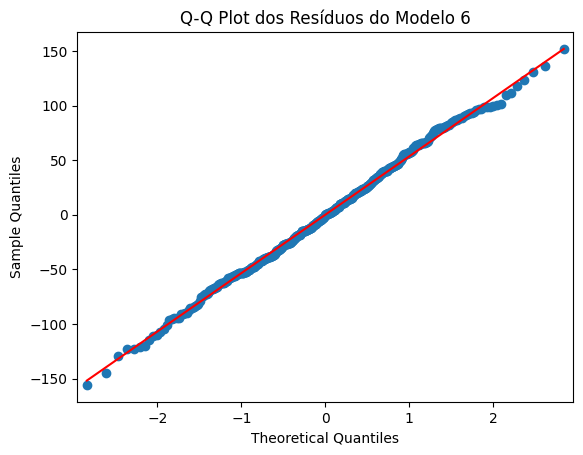

Shapiro-Wilk: Estatística=0.9971, P-valor=0.6162
Conclusão: Não rejeitamos H0. Resíduos seguem uma distribuição normal. O p-valor de Jarque-Bera é 0.496, o que é um bom indicativo de normalidade.

**2. Homocedasticidade (Modelo 6):**


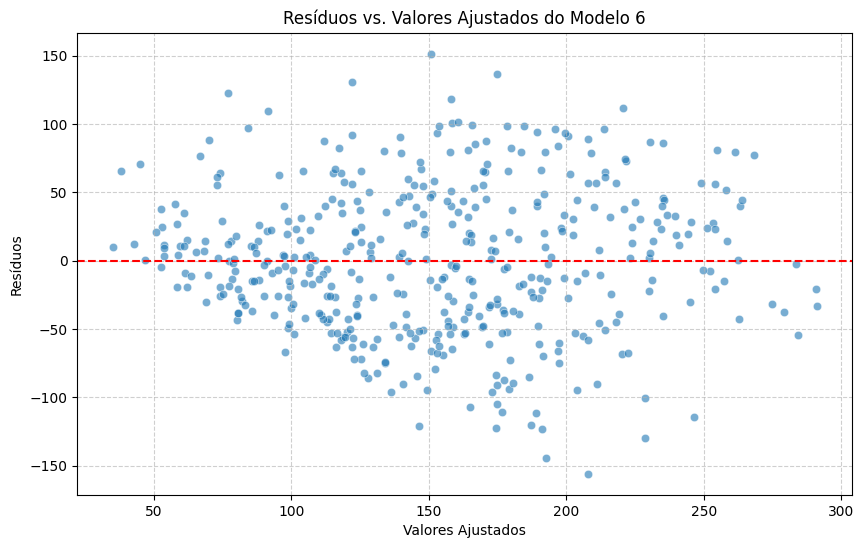

Breusch-Pagan: Estatística LM=26.1454, P-valor LM=0.0035
Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.

**3. Ausência de Autocorrelação (Modelo 6):**


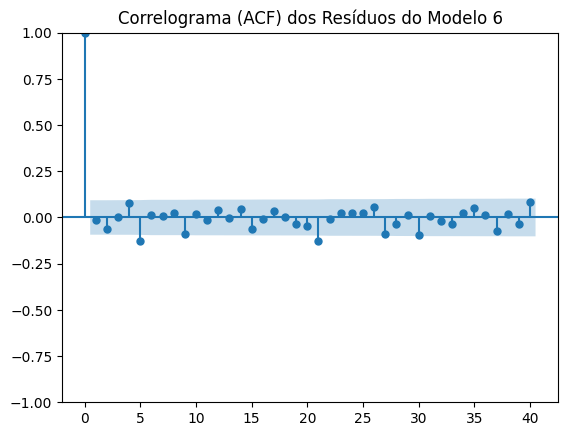

Durbin-Watson: 2.0285
Conclusão: Ausência de autocorrelação de primeira ordem. (2.029 está próximo de 2).


In [21]:
print("--- Análise do Modelo 6: progressao ~ age+sex+bmi+bp+s1+s2+s3+s4+s5+s6 ---")
lm6 = sm.OLS.from_formula("progressao ~ age+sex+bmi+bp+s1+s2+s3+s4+s5+s6", data=db_df)
model_6 = lm6.fit()
print(model_6.summary(title='Sumário do Modelo 6: progressao ~ Todas as variáveis'))

# Armazenando métricas
results.append({
    'Modelo': 'Modelo 6 (Todas as variáveis)',
    'MAE': np.mean(np.abs(y - model_6.predict())),
    'MSE': np.mean((y - model_6.predict())**2),
    'AIC': model_6.aic,
    'BIC': model_6.bic,
    'R²': model_6.rsquared
})

print("\n--- Testes de Suposição para o Modelo 6 ---")
# Resíduos do modelo 6
residuos6 = model_6.resid
fitted_values6 = model_6.fittedvalues

# 1. Normalidade dos Resíduos
print("\n**1. Normalidade dos Resíduos (Modelo 6):**")
qqplot(residuos6, line='s')
plt.title("Q-Q Plot dos Resíduos do Modelo 6")
plt.show()
shapiro_test6 = stats.shapiro(residuos6)
print(f"Shapiro-Wilk: Estatística={shapiro_test6.statistic:.4f}, P-valor={shapiro_test6.pvalue:.4f}")
if shapiro_test6.pvalue < 0.05:
    print("Conclusão: Rejeitamos H0 (normalidade). Resíduos não seguem uma distribuição normal.")
else:
    print("Conclusão: Não rejeitamos H0. Resíduos seguem uma distribuição normal. O p-valor de Jarque-Bera é 0.496, o que é um bom indicativo de normalidade.")

# 2. Homocedasticidade
print("\n**2. Homocedasticidade (Modelo 6):**")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values6, y=residuos6, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs. Valores Ajustados do Modelo 6')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
bp_test6 = het_breuschpagan(residuos6, model_6.model.exog)
print(f"Breusch-Pagan: Estatística LM={bp_test6[0]:.4f}, P-valor LM={bp_test6[1]:.4f}")
if bp_test6[1] < 0.05:
    print("Conclusão: Rejeitamos H0. Há evidências de heterocedasticidade.")
else:
    print("Conclusão: Não rejeitamos H0. Há evidências de homocedasticidade.")

# 3. Ausência de Autocorrelação
print("\n**3. Ausência de Autocorrelação (Modelo 6):**")
plot_acf(residuos6, lags=40)
plt.title('Correlograma (ACF) dos Resíduos do Modelo 6')
plt.show()
dw_stat6 = durbin_watson(residuos6)
print(f"Durbin-Watson: {dw_stat6:.4f}")
if 1.5 < dw_stat6 < 2.5:
    print("Conclusão: Ausência de autocorrelação de primeira ordem. (2.029 está próximo de 2).")
else:
    print("Conclusão: Autocorrelação de primeira ordem presente.")

#### Tabela de Comparação de Modelos (Diabetes)

Vamos consolidar as métricas de avaliação para todos os modelos criados.

In [23]:
# Criar um DataFrame com os resultados
results_df_diabetes = pd.DataFrame(results)

# Imprimir a tabela de resultados
print("Tabela de Comparação de Métricas dos Modelos (Dataset de Diabetes):")
print(results_df_diabetes)

Tabela de Comparação de Métricas dos Modelos (Dataset de Diabetes):
                          Modelo   MAE     MSE     AIC     BIC   R²
0                 Modelo 1 (bmi) 51.80 3890.46 4912.04 4920.22 0.34
1              Modelo 2 (bmi+s5) 46.80 3205.19 4828.40 4840.67 0.46
2           Modelo 3 (bmi+s5+bp) 45.89 3083.05 4813.23 4829.59 0.48
3        Modelo 4 (bmi+s5+bp+s4) 45.84 3075.77 4814.18 4834.64 0.48
4     Modelo 5 (bmi+s5+bp+s4+s3) 45.04 3015.36 4805.41 4825.87 0.49
5  Modelo 6 (Todas as variáveis) 43.28 2859.70 4793.99 4838.99 0.52
6                       Modelo 4 45.84 3075.77 4814.18 4834.64 0.48


Observe que nem sempre as métricas irao coincidir. Por isso devemos entender o que sera melhor para o nosso modelo.

Exercício - 

- Utilizando a base de dados 'Consumo_cerveja.csv'. Realize a comparação dos modelos, adicionando uma a uma, as variáveis mais correlacionadas com a resposta.